# 3. Check the methane-sensitive bands

This notebook asks whether the plume pixels contain a methane-shaped signal before using a matched filter. The 2.3 micrometre window is the main retrieval window. The weaker 1.65 micrometre window is kept as a cross-check.

## Load the two scenes

The code reads the radiance and surface-reflectance cubes downloaded into `data/ghg`. All figures are saved in the top-level `figures` folder.

In [1]:
import h5py, gc, warnings
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path
import geopandas as gpd
import hypercoast as hc
warnings.filterwarnings('ignore')

from pathlib import Path
import sys

PACKAGE_ROOT = Path.cwd().resolve()
while not (PACKAGE_ROOT / "scripts").is_dir() and PACKAGE_ROOT.parent != PACKAGE_ROOT:
    PACKAGE_ROOT = PACKAGE_ROOT.parent
if not (PACKAGE_ROOT / "scripts").is_dir():
    raise FileNotFoundError("Run this notebook from the cloned submission folder or its notebooks folder.")

sys.path.insert(0, str(PACKAGE_ROOT / "scripts"))

FIG_DIR = PACKAGE_ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
ROOT=PACKAGE_ROOT / 'data' / 'ghg'; NORTH_ID='20250423_134021_00_4001'; SOUTH_ID='20250423_134026_31_4001'
RAD_DS='HDFEOS/GRIDS/HYP/Data Fields/toa_radiance'; SR_DS='HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance'
WVP_DS='HDFEOS/GRIDS/HYP/Data Fields/column_water_vapour'
CLOUD='HDFEOS/GRIDS/HYP/Data Fields/beta_cloud_mask'; CIRRUS='HDFEOS/GRIDS/HYP/Data Fields/beta_cirrus_mask'
NODATA='HDFEOS/GRIDS/HYP/Data Fields/nodata_pixels'; FILL=-9999.0
paths={'north_rad':ROOT/NORTH_ID/'ortho_radiance_hdf5.h5','north_sr':ROOT/NORTH_ID/'ortho_sr_hdf5.h5',
       'south_rad':ROOT/SOUTH_ID/'ortho_radiance_hdf5.h5','south_sr':ROOT/SOUTH_ID/'ortho_sr_hdf5.h5',
       'north_geojson':ROOT/NORTH_ID/'ql_ch4_json.geojson','south_geojson':ROOT/SOUTH_ID/'ql_ch4_json.geojson'}
with h5py.File(paths['north_rad'],'r') as f:
    wavelengths=f[RAD_DS].attrs['wavelengths'][:].astype(float); fwhm=f[RAD_DS].attrs['fwhm'][:].astype(float)
with h5py.File(paths['north_sr'],'r') as f:
    good_wl=f[SR_DS].attrs['good_wavelengths'][:]

# Two bands: 2.3 um primary, 1.65 um secondary. ic/il/ir = index centre/left/right; wc/ws = residual centre/shoulders.
BANDS={'23':dict(label='2.3 µm',sfx='',primary=True,ic=(2300,2375),il=(2200,2260),ir=(2400,2460),
                 wc=(2300,2375),ws=[(2200,2260),(2400,2460)],xlim=(2150,2470),ylim=(0.82,1.08),shade=(2300,2375)),
       '165':dict(label='1.65 µm',sfx='_165',primary=False,ic=(1650,1685),il=(1520,1600),ir=(1715,1760),
                 wc=(1640,1690),ws=[(1520,1600),(1715,1760)],xlim=(1550,1800),ylim=(0.90,1.05),shade=(1640,1690))}
PLUME_DELTA, BG_DELTA = 0.0006, 0.006

def load_plumes(geojson):
    gdf=gpd.read_file(geojson); out=[]
    for _,r in gdf.iterrows():
        g=r.geometry; lon,lat=(g.x,g.y) if g.geom_type=='Point' else (g.centroid.x,g.centroid.y)
        pid=str(r.get('plume_id','-'))
        out.append({'label':pid.split('_strip_')[-1] if '_strip_' in pid else pid,
                    'quality':r.get('plume_quality','-'),'emission':float(r.get('emission',np.nan)),'lon':lon,'lat':lat})
    return out
north_plumes=load_plumes(paths['north_geojson']); south_plumes=load_plumes(paths['south_geojson'])
def wmask(lo,hi): return (wavelengths>=lo)&(wavelengths<=hi)
print('windows ready | plumes:',[f"strip_{p['label']}({p['quality']})" for p in north_plumes+south_plumes])


windows ready | plumes: ['strip_C(good)', 'strip_A(questionable)', 'strip_B(good)']


## Wavelength coverage

This plot confirms that Tanager samples both methane windows and shows the band widths used in the analysis.

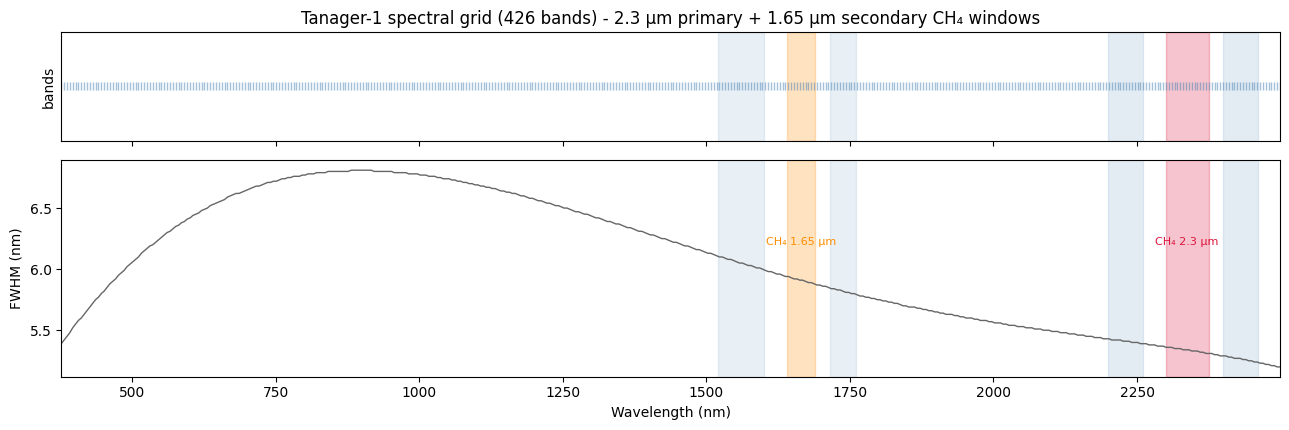

Saved 01_wavelength_array.png


In [2]:
fig,(axg,axf)=plt.subplots(2,1,figsize=(13,4.4),sharex=True,gridspec_kw={'height_ratios':[1,2]})
axg.plot(wavelengths,np.ones_like(wavelengths),'|',color='steelblue',ms=6,alpha=.5); axg.set_yticks([]); axg.set_ylabel('bands')
axg.set_title('Tanager-1 spectral grid (426 bands) - 2.3 µm primary + 1.65 µm secondary CH₄ windows')
axf.plot(wavelengths,fwhm,color='0.4',lw=1); axf.set_xlabel('Wavelength (nm)'); axf.set_ylabel('FWHM (nm)')
for ax in (axg,axf):
    ax.axvspan(2300,2375,color='crimson',alpha=.25); ax.axvspan(2200,2260,color='steelblue',alpha=.15); ax.axvspan(2400,2460,color='steelblue',alpha=.15)
    ax.axvspan(1640,1690,color='darkorange',alpha=.25); ax.axvspan(1520,1600,color='steelblue',alpha=.12); ax.axvspan(1715,1760,color='steelblue',alpha=.12)
    ax.set_xlim(wavelengths[0],wavelengths[-1])
axf.text(2337,axf.get_ylim()[1]*.9,'CH₄ 2.3 µm',color='crimson',ha='center',fontsize=8)
axf.text(1665,axf.get_ylim()[1]*.9,'CH₄ 1.65 µm',color='darkorange',ha='center',fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR/'03_wavelength_coverage.png',dpi=150,bbox_inches='tight'); plt.show(); print('Saved 01_wavelength_array.png')


## Build plume and background spectra

For each provider plume location, the code samples nearby plume pixels and a local background from the same scene.

In [3]:
def ch4_index_map(cube,b):
    centre=cube.sel(wavelength=slice(*b['ic'])).mean('wavelength').values
    left  =cube.sel(wavelength=slice(*b['il'])).mean('wavelength').values
    right =cube.sel(wavelength=slice(*b['ir'])).mean('wavelength').values
    with np.errstate(invalid='ignore',divide='ignore'): return 1.0-centre/(0.5*(left+right))

def process_cube(path, points, want_maps=False, control=None):
    ds=hc.read_tanager(path); var='surface_reflectance' if 'surface_reflectance' in ds.data_vars else 'toa_radiance'
    cube=ds[var]; lat2d,lon2d=ds.latitude.values,ds.longitude.values
    out={'var':var,'background':cube.median(dim=('y','x')).values}
    if control is not None:
        out['control']={'spec':hc.extract_tanager(ds,control[0],control[1],delta=PLUME_DELTA).values,
                        'bg_local':hc.extract_tanager(ds,control[0],control[1],delta=BG_DELTA).values}
    refs={}
    if want_maps:
        with h5py.File(path,'r') as f:
            bad=((f[CLOUD][()]==1)|(f[CIRRUS][()]==1)|(f[NODATA][()]==1)|(f[CLOUD][()]==255))
        out['bad']=bad
        for bk,b in BANDS.items():
            idx=ch4_index_map(cube,b); ocean=np.where(bad,np.nan,idx)
            out['idx_'+bk]=np.where(bad,np.nan,idx); refs[bk]=(np.nanmedian(ocean),np.nanstd(ocean))
    pts=[]
    for p in points:
        d2=(lat2d-p['lat'])**2+(lon2d-p['lon'])**2; row,col=map(int,np.unravel_index(np.nanargmin(d2),d2.shape))
        q={**p,'row':row,'col':col,'spec':hc.extract_tanager(ds,p['lat'],p['lon'],delta=PLUME_DELTA).values,
           'bg_local':hc.extract_tanager(ds,p['lat'],p['lon'],delta=BG_DELTA).values}
        if want_maps:
            for bk in BANDS:
                box=out['idx_'+bk][max(0,row-2):row+3,max(0,col-2):col+3]
                q['sigma_'+bk]=(np.nanmean(box)-refs[bk][0])/refs[bk][1]
        pts.append(q)
    out['points']=pts; del ds,cube; gc.collect(); return out

print('Reading 4 ortho cubes (~4.8 GB each, freed after use)...')
LIB={}
LIB['rad_N']=process_cube(paths['north_rad'],north_plumes,want_maps=True,control=(-25.30,-42.80))
LIB['rad_S']=process_cube(paths['south_rad'],south_plumes,want_maps=True,control=(-25.66,-42.95))
LIB['sr_N']=process_cube(paths['north_sr'],north_plumes); LIB['sr_S']=process_cube(paths['south_sr'],south_plumes)
for k,v in LIB.items(): print(f"  {k}: {v['var']:<19s} {len(v['points'])} plume(s)")


Reading 4 ortho cubes (~4.8 GB each, freed after use)...


  rad_N: toa_radiance        1 plume(s)
  rad_S: toa_radiance        2 plume(s)
  sr_N: surface_reflectance 1 plume(s)
  sr_S: surface_reflectance 2 plume(s)


## Compare plume and background spectra

The plots show the measured spectra before any matched filtering.

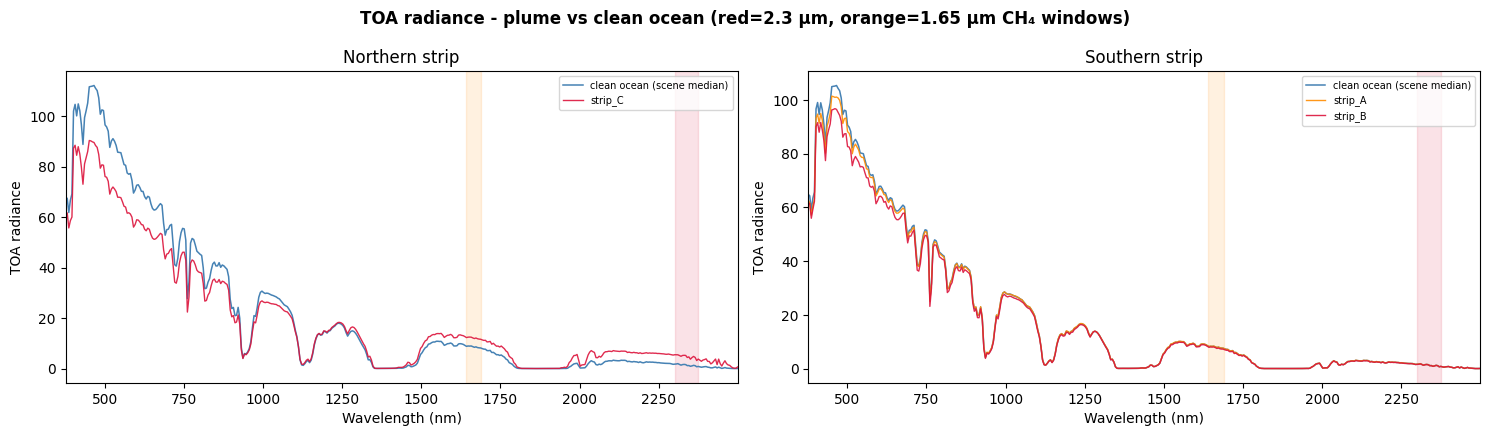

Saved 02_radiance_spectra.png


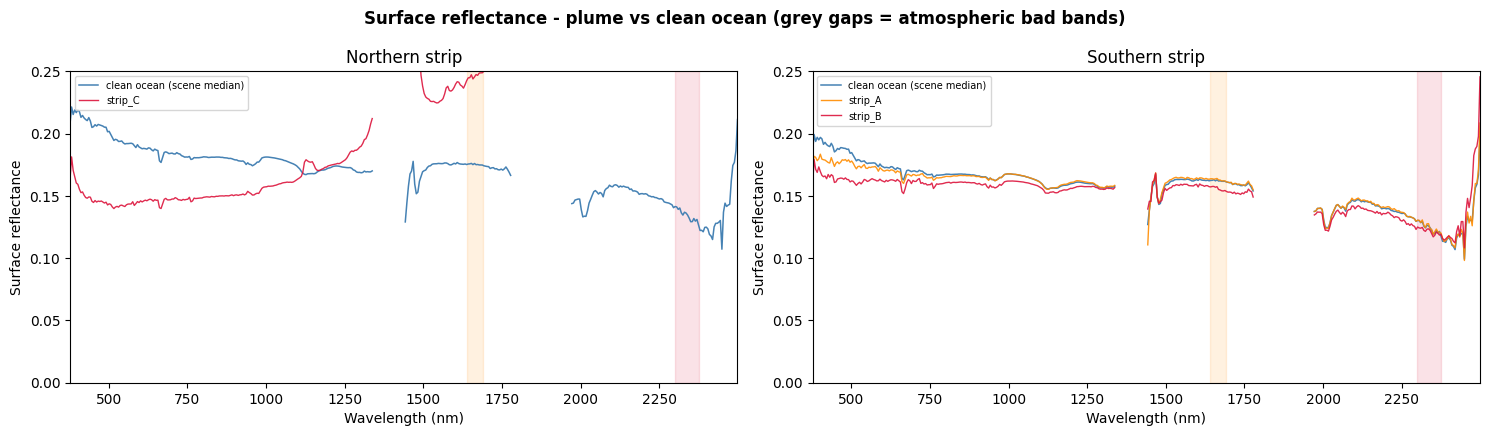

Saved 03_sr_spectra.png


In [4]:
# Radiance (fig 02)
fig,axes=plt.subplots(1,2,figsize=(15,4.4))
for ax,key,title in [(axes[0],'rad_N','Northern strip'),(axes[1],'rad_S','Southern strip')]:
    L=LIB[key]; ax.plot(wavelengths,L['background'],color='steelblue',lw=1.1,label='clean ocean (scene median)')
    for q in L['points']:
        c='crimson' if q['quality']=='good' else 'darkorange'
        ax.plot(wavelengths,q['spec'],lw=1.0,color=c,alpha=.9,label=f"strip_{q['label']}")
    ax.axvspan(2300,2375,color='crimson',alpha=.12); ax.axvspan(1640,1690,color='darkorange',alpha=.12)
    ax.set_title(title); ax.set_xlabel('Wavelength (nm)'); ax.set_ylabel('TOA radiance'); ax.set_xlim(wavelengths[0],wavelengths[-1]); ax.legend(fontsize=7)
plt.suptitle('TOA radiance - plume vs clean ocean (red=2.3 µm, orange=1.65 µm CH₄ windows)',fontweight='bold')
plt.tight_layout(); plt.savefig(FIG_DIR/'03_radiance_spectra.png',dpi=150,bbox_inches='tight'); plt.show(); print('Saved 02_radiance_spectra.png')
# Surface reflectance (fig 03)
bad=good_wl==0
fig,axes=plt.subplots(1,2,figsize=(15,4.4))
for ax,key,title in [(axes[0],'sr_N','Northern strip'),(axes[1],'sr_S','Southern strip')]:
    L=LIB[key]; bg=L['background'].copy(); bg[bad]=np.nan; ax.plot(wavelengths,bg,color='steelblue',lw=1.1,label='clean ocean (scene median)')
    for q in L['points']:
        s=q['spec'].copy(); s[bad]=np.nan; c='crimson' if q['quality']=='good' else 'darkorange'
        ax.plot(wavelengths,s,lw=1.0,color=c,alpha=.9,label=f"strip_{q['label']}")
    ax.axvspan(2300,2375,color='crimson',alpha=.12); ax.axvspan(1640,1690,color='darkorange',alpha=.12)
    ax.set_title(title); ax.set_xlabel('Wavelength (nm)'); ax.set_ylabel('Surface reflectance'); ax.set_xlim(wavelengths[0],wavelengths[-1]); ax.set_ylim(0,0.25); ax.legend(fontsize=7)
plt.suptitle('Surface reflectance - plume vs clean ocean (grey gaps = atmospheric bad bands)',fontweight='bold')
plt.tight_layout(); plt.savefig(FIG_DIR/'03_surface_reflectance_spectra.png',dpi=150,bbox_inches='tight'); plt.show(); print('Saved 03_sr_spectra.png')


## Check water vapour

Water vapour can change the spectrum near methane bands. This check shows whether the selected signal follows methane rather than the strongest water-vapour structure.

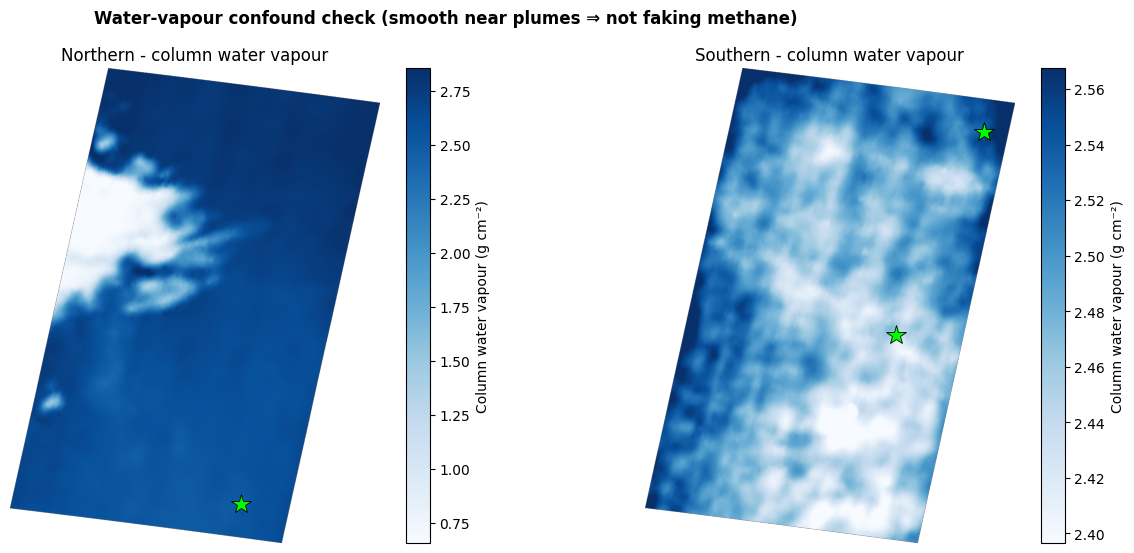

Saved 06_wvp.png


In [5]:
def read_2d(path,ds_int):
    with h5py.File(path,'r') as f: a=f[ds_int][()].astype(float)
    a[a<=-9999+1]=np.nan; return a
fig,axes=plt.subplots(1,2,figsize=(14,5.6))
for ax,key,sr_path,title in [(axes[0],'rad_N',paths['north_sr'],'Northern - column water vapour'),
                             (axes[1],'rad_S',paths['south_sr'],'Southern - column water vapour')]:
    arr=read_2d(sr_path,WVP_DS); vmin,vmax=np.nanpercentile(arr,[2,98]); im=ax.imshow(arr,cmap='Blues',vmin=vmin,vmax=vmax)
    plt.colorbar(im,ax=ax,fraction=.046,pad=.04,label='Column water vapour (g cm⁻²)')
    for q in LIB[key]['points']: ax.plot(q['col'],q['row'],'*',color='lime',ms=15,mec='k',mew=.6)
    ax.set_title(title); ax.axis('off')
plt.suptitle('Water-vapour confound check (smooth near plumes ⇒ not faking methane)',fontweight='bold')
plt.tight_layout(); plt.savefig(FIG_DIR/'03_water_vapour_check.png',dpi=150,bbox_inches='tight'); plt.show(); print('Saved 06_wvp.png')


## Plot helpers

The same calculations are used for both methane windows so the comparison is consistent.

In [6]:
def ch4_residual(plume,background,b):
    W_CENTER=wmask(*b['wc']); W_CONT=np.zeros_like(wavelengths,bool)
    for lo,hi in b['ws']: W_CONT|=wmask(lo,hi)
    r=np.asarray(plume,float)/np.asarray(background,float); m=W_CONT&np.isfinite(r)&(r>0)
    if m.sum()<5: return np.full_like(r,np.nan),np.nan,np.nan,np.nan
    coef=np.polyfit(wavelengths[m],np.log(r[m]),1); resid=r/np.exp(np.polyval(coef,wavelengths))
    depth=1.0-np.nanmean(resid[W_CENTER]); noise=np.nanstd(resid[W_CONT])
    return resid,depth,noise,(depth/noise if noise>0 else np.nan)

def fig_residual(bk):
    b=BANDS[bk]
    fig,axes=plt.subplots(1,2,figsize=(15,4.6))
    for ax,key,title in [(axes[0],'rad_N','Northern strip'),(axes[1],'rad_S','Southern strip')]:
        L=LIB[key]
        for q in L['points']:
            resid,depth,noise,snr=ch4_residual(q['spec'],q['bg_local'],b); c='crimson' if q['quality']=='good' else 'darkorange'
            ax.plot(wavelengths,resid,color=c,lw=1.6,label=f"strip_{q['label']}: {100*depth:.1f}% dip, SNR {snr:.1f}, map {q.get('sigma_'+bk,float('nan')):.1f}σ")
        ctrl=L.get('control')
        if ctrl:
            resid,depth,_,_=ch4_residual(ctrl['spec'],ctrl['bg_local'],b)
            ax.plot(wavelengths,resid,color='0.55',lw=1.2,ls=':',label=f'clean-ocean null ({100*depth:.1f}% dip)')
        ax.axhline(1,color='k',lw=.8); ax.axvspan(*b['shade'],color='crimson',alpha=.15)
        ax.set_xlim(*b['xlim']); ax.set_ylim(*b['ylim']); ax.set_title(f'{title} - CH₄ dip at {b["label"]}')
        ax.set_xlabel('Wavelength (nm)'); ax.set_ylabel('continuum-normalised plume / local ocean'); ax.legend(fontsize=7.5,loc='lower left')
    plt.suptitle(f'CH₄ band-depth residual at {b["label"]} (local brightness-matched background)',fontweight='bold')
    plt.tight_layout(); plt.savefig(FIG_DIR/f'03_ch4_residual{b["sfx"]}.png',dpi=150,bbox_inches='tight'); plt.show(); print(f'Saved 04_ch4_residual{b["sfx"]}.png')

def fig_index(bk):
    b=BANDS[bk]
    fig,axes=plt.subplots(1,2,figsize=(14,6.2))
    for ax,key,title in [(axes[0],'rad_N','Northern strip'),(axes[1],'rad_S','Southern strip')]:
        L=LIB[key]; idx=L['idx_'+bk]; vmin,vmax=np.nanpercentile(idx,[60,99.5]); im=ax.imshow(idx,cmap='inferno',vmin=vmin,vmax=vmax)
        plt.colorbar(im,ax=ax,fraction=.046,pad=.04,label=f'CH₄ absorption index @{b["label"]} (cloud-masked)')
        for q in L['points']:
            ec='cyan' if q['quality']=='good' else 'yellow'
            ax.plot(q['col'],q['row'],'o',mfc='none',mec=ec,ms=16,mew=1.6)
            ax.annotate(f"strip_{q['label']} ({q.get('sigma_'+bk,float('nan')):.1f}σ)",(q['col'],q['row']),color=ec,fontsize=8,xytext=(8,8),textcoords='offset points')
        ax.set_title(f"{title} - CH₄ index @ {b['label']}"); ax.axis('off')
    plt.suptitle(f'Per-pixel CH₄ absorption index at {b["label"]}',fontweight='bold')
    plt.tight_layout(); plt.savefig(FIG_DIR/f'03_ch4_index_map{b["sfx"]}.png',dpi=150,bbox_inches='tight'); plt.show(); print(f'Saved 03_ch4_index_map{b["sfx"]}.png')

def fig_rad_vs_sr(bk):
    b=BANDS[bk]; pairs=[('strip_C','rad_N','sr_N','C'),('strip_B','rad_S','sr_S','B')]
    fig,axes=plt.subplots(1,2,figsize=(15,4.6))
    for ax,(name,rk,sk,lbl) in zip(axes,pairs):
        def rf(key): q=next(x for x in LIB[key]['points'] if x['label']==lbl); return ch4_residual(q['spec'],q['bg_local'],b)
        rres,rd,_,rs=rf(rk); sres,sd,_,ss=rf(sk)
        ax.plot(wavelengths,rres,color='crimson',lw=1.6,label=f'radiance ({100*rd:.1f}%, SNR {rs:.1f})')
        ax.plot(wavelengths,sres,color='steelblue',lw=1.6,label=f'surface refl ({100*sd:.1f}%, SNR {ss:.1f})')
        ax.axhline(1,color='k',lw=.8); ax.axvspan(*b['shade'],color='crimson',alpha=.12); ax.set_xlim(*b['xlim']); ax.set_ylim(*b['ylim'])
        ax.set_title(f'{name} - radiance vs SR at {b["label"]}'); ax.legend(fontsize=8); ax.set_xlabel('Wavelength (nm)'); ax.set_ylabel('continuum-normalised plume / local ocean')
    plt.suptitle(f'Which product gives the cleaner CH₄ dip at {b["label"]}-',fontweight='bold')
    plt.tight_layout(); plt.savefig(FIG_DIR/f'03_radiance_vs_reflectance{b["sfx"]}.png',dpi=150,bbox_inches='tight'); plt.show(); print(f'Saved 07_rad_vs_sr_decision{b["sfx"]}.png')
print('Diagnostic helpers ready.')


Diagnostic helpers ready.


# Main test: 2.3 micrometres

## Methane residual

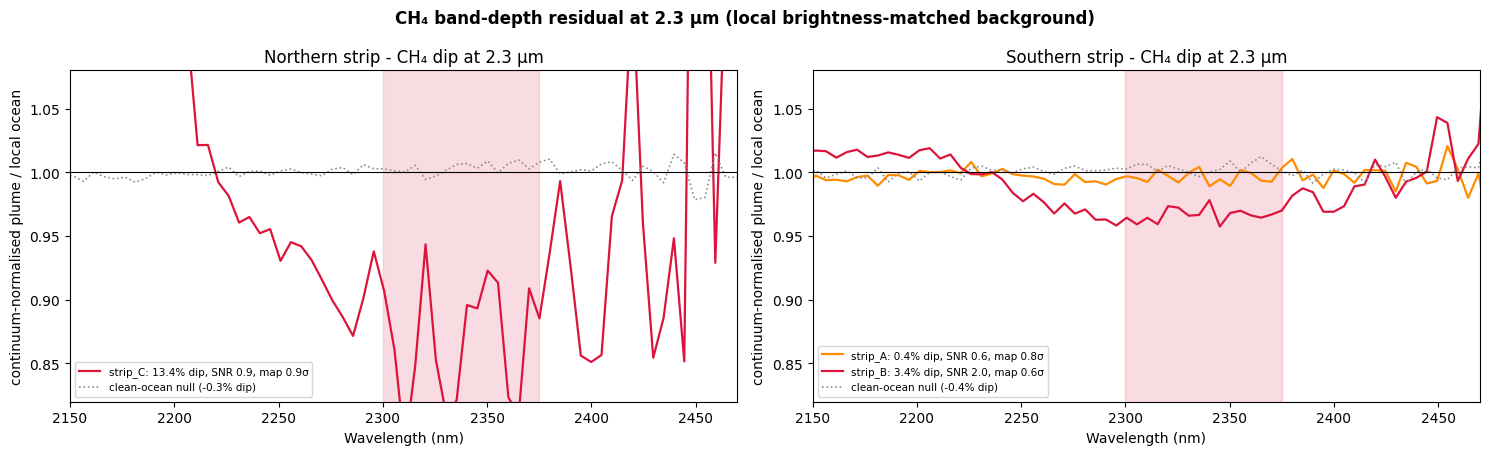

Saved 04_ch4_residual.png


In [7]:
fig_residual('23')


## Simple methane index map

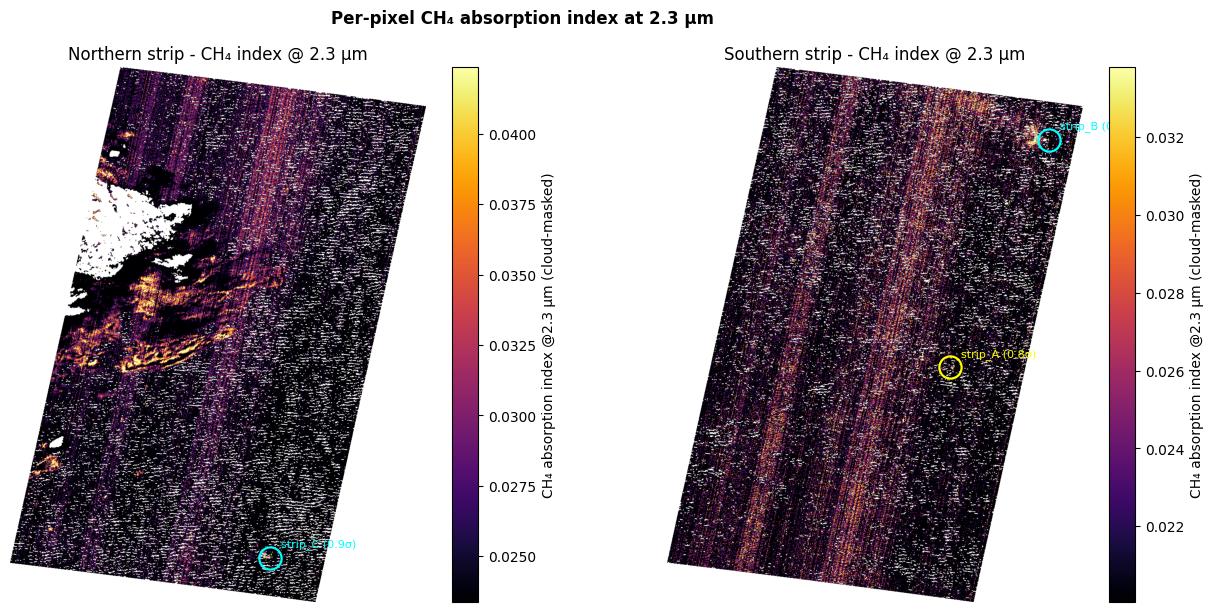

Saved 03_ch4_index_map.png


In [8]:
fig_index('23')


## Choose radiance or surface reflectance

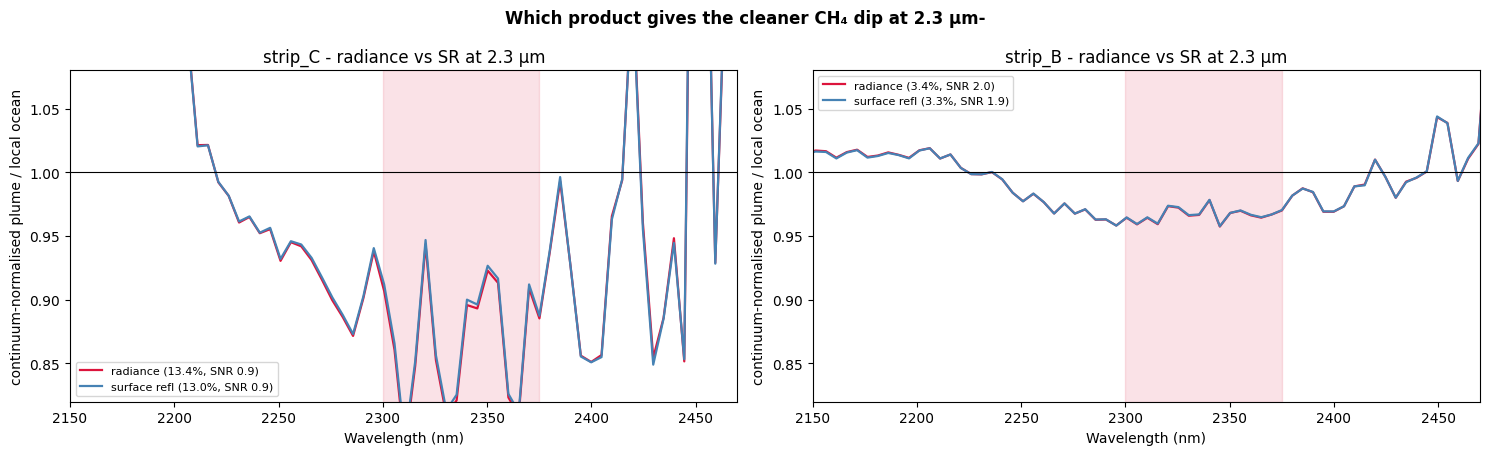

Saved 07_rad_vs_sr_decision.png


In [9]:
fig_rad_vs_sr('23')


# Cross-check: 1.65 micrometres

## Methane residual

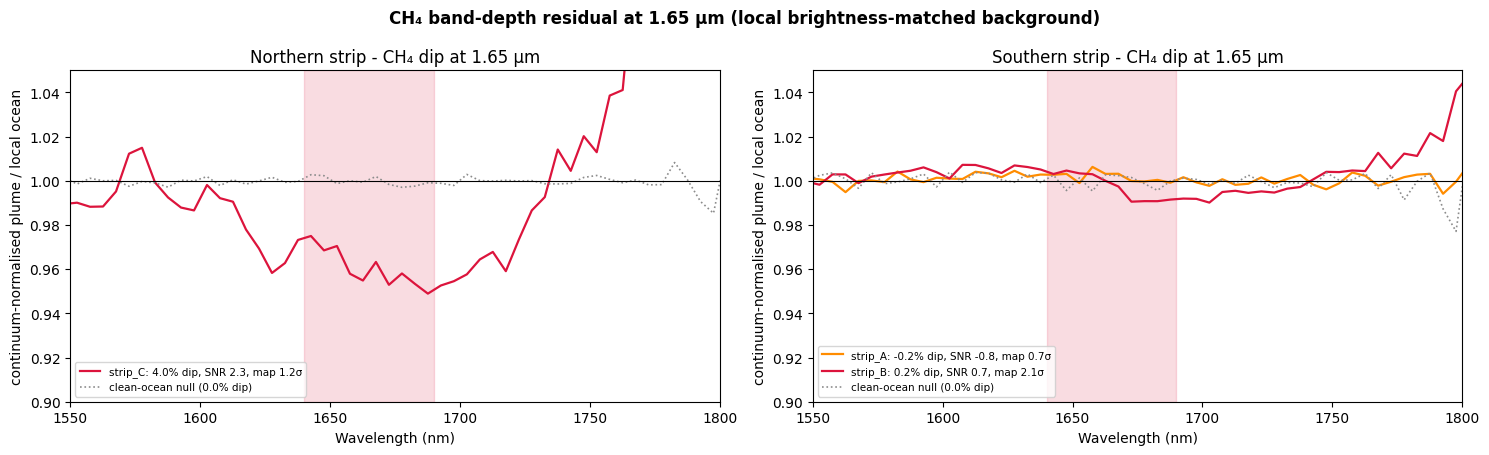

Saved 04_ch4_residual_165.png


In [10]:
fig_residual('165')


## Simple methane index map

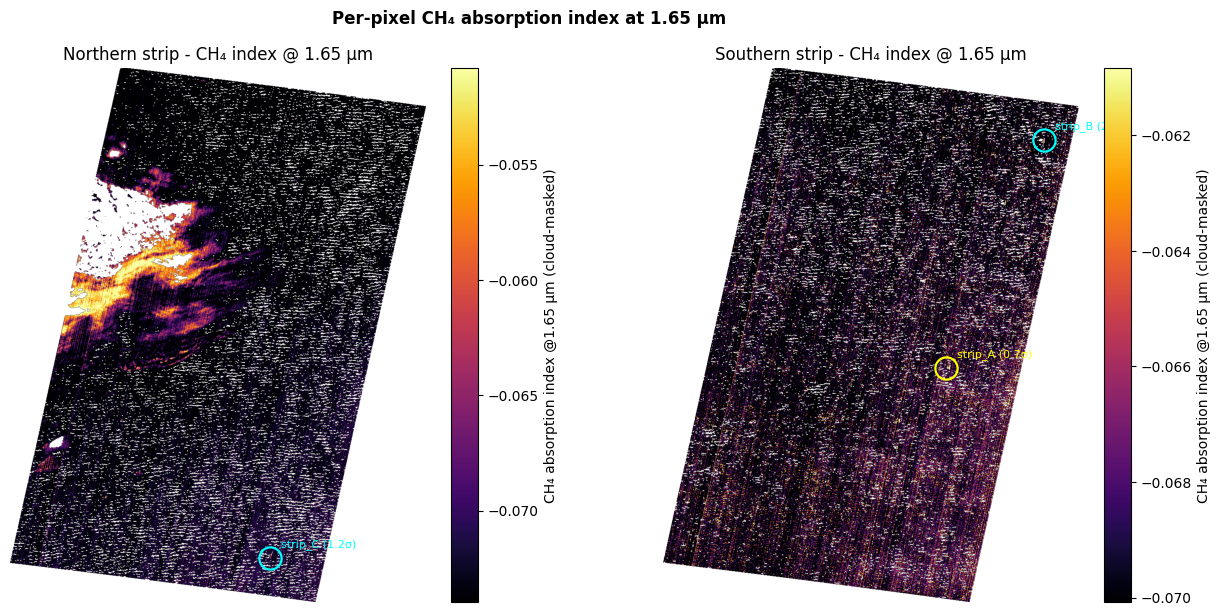

Saved 03_ch4_index_map_165.png


In [11]:
fig_index('165')


## Choose radiance or surface reflectance

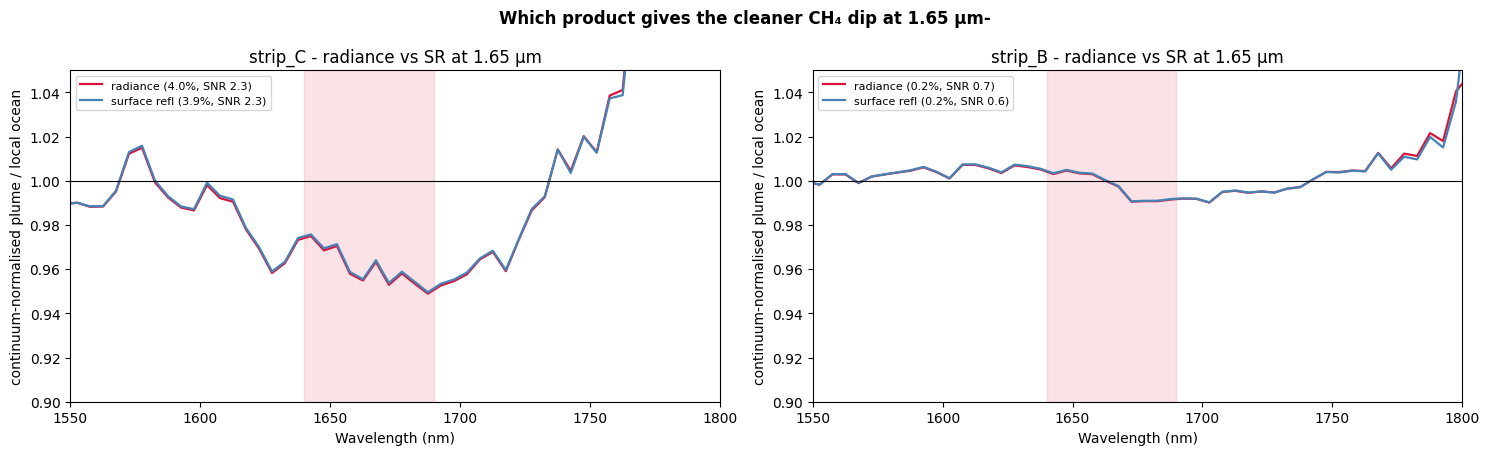

Saved 07_rad_vs_sr_decision_165.png


In [12]:
fig_rad_vs_sr('165')


## Result

The 2.3 micrometre window gives the clearer plume signal and is used for the main matched-filter result. The 1.65 micrometre result is retained as a secondary check rather than treated as an independent confirmation.